In [1]:
# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
# NOTE: PYTHONPATH must be set correctly to include the project src directory
# in order to find the nndl module file
from nndl import vectorize_samples, plot_history

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

I0000 00:00:1779042045.888814    1723 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779042046.454322    1723 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 5: Fundamentals of Machine Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit we will attempt to improve and formalize some of these intuitions about
machine learning into a solid conceptual framework.  Being good at building machine learning
models  means that you know how to accurately evaluate models, and how to balance between
training and generalization.


## 5.1 Generalization: The goal of machine learning

### 5.1.1 Underfitting and overfitting

At the beginning of training, optimization and generalization are correlated: the
lower the loss on training data, the lower the loss on test data. While this is happening,
your model is said to be **underfit**: there is still progress to be made

But after a certain number of iterations on the training data, generalization stops improving, validation metrics stall
and then begin to degrade: the model is starting to **overfit**.  Overfitting is particularly likely to occur when
your data is noisy, if it involves uncertainty, or if it includes rare features.  

#### Noisy training data

#### Ambiguous features


#### Rare features and spurious correlations

Machine learning models trained on datasets that include rare feature
values are highly susceptible to overfitting. Importantly, a feature value doesn't need
to occur only a couple of times to lead to spurious correlations.

Here’s a striking example. Take MNIST. Create a new training set by concatenating
784 white noise dimensions to the existing 784 dimensions of the data, so half of the
data is now noise. For comparison, also create an equivalent dataset by concatenating
784 all-zeros dimensions. Our concatenation of meaningless features does not at all
affect the information content of the data: we’re only adding something. Human classification
accuracy wouldn’t be affected by these transformations at all.

In [3]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1)
train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 24s 2us/step


In [4]:
def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8103 - loss: 0.6192 - val_accuracy: 0.9205 - val_loss: 0.2605
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9210 - loss: 0.2549 - val_accuracy: 0.9341 - val_loss: 0.2150
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9486 - loss: 0.1647 - val_accuracy: 0.9466 - val_loss: 0.1703
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9625 - loss: 0.1197 - val_accuracy: 0.9588 - val_loss: 0.1386
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9723 - loss: 0.0867 - val_accuracy: 0.9579 - val_loss: 0.1407
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9806 - loss: 0.0634 - val_accuracy: 0.9628 - val_loss: 0.1273
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9852 - loss: 0.0472 - val_accuracy: 0.9612 - val_loss: 0.1346
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.

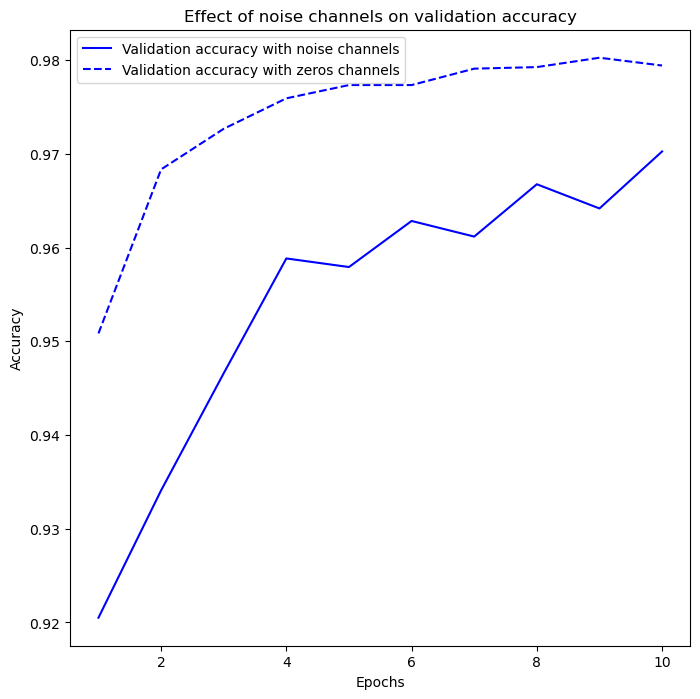

In [5]:
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
         label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
         label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();

Despite the data holding the same information in both cases, the validation accuracy
of the model trained with noise channels ends up about one percentage point lower, 
purely through the influence of spurious correlations. The more
noise channels you add, the further accuracy will degrade. 
**Noisy features inevitably lead to overfitting.**

As such, a common data exploration step in machine learning is to do a
**feature selection** or **feature importance** determination.  Restricting the
IMDB data to the top 10,000 most common words was a form of feature selection.
The typical way to do feature selection is to compute some usefulness score for each
feature available, a measure of how informative the feature is with respect to the
label.

### 5.1.2 The nature of generalization in deep learning

A remarkable fact about deep learning models is that they can be trained to fit anything,
as long as they have enough representational power.

Just to prove it, if you randomly shuffle the labels of the MNIST dataset and train a model
(of sufficient power) on that, the training loss will go down just fine and look normal.
The validation loss will not improve since there is no possibility of generalization for
random data.

In [6]:
# get the mnist training data
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

# copy the labels and randomly shuffle them
random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)


model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# the validation_split will split 20% of the data and use
# it for loss validation
history = model.fit(train_images, random_train_labels,
                    epochs=100,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1024 - loss: 2.3154 - val_accuracy: 0.1053 - val_loss: 2.3048
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1169 - loss: 2.2992 - val_accuracy: 0.1024 - val_loss: 2.3143
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1265 - loss: 2.2907 - val_accuracy: 0.1032 - val_loss: 2.3199
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1404 - loss: 2.2791 - val_accuracy: 0.0978 - val_loss: 2.3250
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1512 - loss: 2.2639 - val_accuracy: 0.0978 - val_loss: 2.3365
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1661 - loss: 2.2440 - val_accuracy: 0.1044 - val_loss: 2.3548
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1791 - loss: 2.2205 - val_accuracy: 0.1039 - val_loss: 2.3604
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1955 - loss: 2.1937 - val_accu

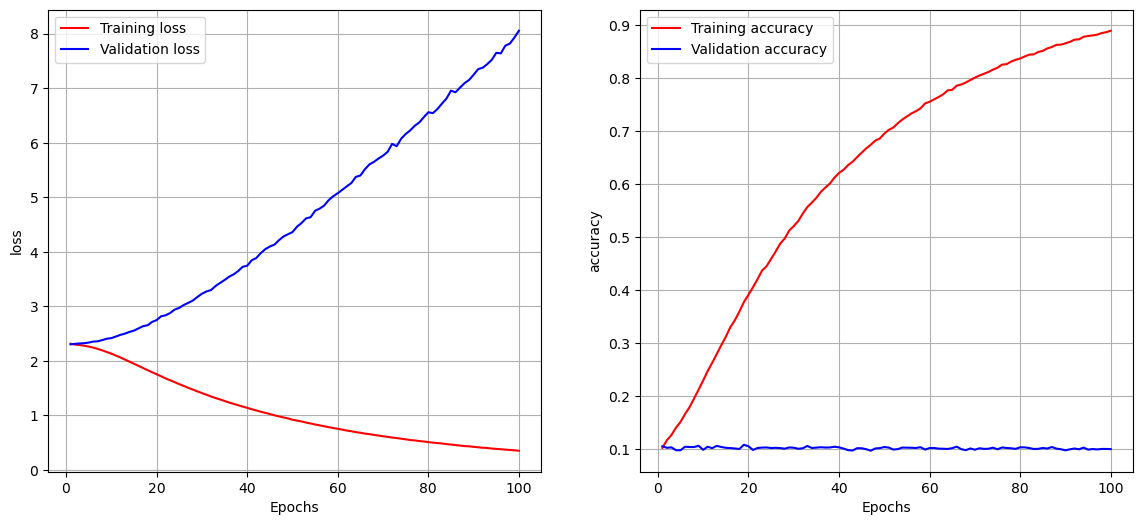

In [7]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

Training loss actually looks about the same as if you trained on real data.  Training accuracy is not as high as you would expect
to see on MNIST, because randomly shuffling the labels makes it tougher to find any actual patterns (it is only learning the noise in
the training data).

For data that has no information you might see accuracy and loss curves like this.  For example though the accuracy improves on the data
it is learning the noise for, actual generalization accuracy on unseen validation data always remains at 10% or random guess
level.

How come deep learning models generalize at all? Shouldn’t
they just learn an ad hoc mapping between training inputs and targets, like a fancy
dict?  The nature of generalization in deep learning has rather little to do
with deep learning models themselves, and much to do with the structure of information
in the real world.

#### The manifold hypothesis

#### Interpolation as a source of generalization

#### Why deep learning works

#### Training data is paramount

## Summary 

To recap, here is what you should remember about generalization, underfitting and overfitting in
neural network models:

<font color='blue'>

- The fundamental issue in machine learning is the tension between optimization and generalization.
- Overfitting always occurs in a deep learning model (it can be trained to fit anything with enough parameters, even noise).
- The ability to interpolate between samples is the key to understanding generalization in deep learning.
- At some intermediate point during training, a deep learning model roughly approximates the natural manifold of the data it is being fitted to.
- For a model to perform well it needs to be trained on a dense sampling of its input space.